In [1]:
# Install and import all required libraries
!pip install pandas numpy matplotlib seaborn faker -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from faker import Faker
import random
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
random.seed(42)
fake = Faker()

print("All libraries imported successfully!")
print("Let's build a Customer Experience Analytics Dashboard!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 38.0 MB/s eta 0:00:00
All libraries imported successfully!
Let's build a Customer Experience Analytics Dashboard!


In [2]:
# Generate Customer Experience Dataset
n_customers = 5000
n_interactions = 25000

channels = ['Website', 'Mobile App', 'Phone', 'Email', 'Live Chat', 'In-Store']
touchpoints = ['Onboarding', 'Purchase', 'Support', 'Renewal', 'Complaint', 'Feedback']
products = ['Basic Plan', 'Pro Plan', 'Enterprise Plan', 'Add-on Services']
regions = ['North America', 'Europe', 'Asia Pacific', 'Latin America']
age_groups = ['18-25', '26-35', '36-45', '46-55', '55+']
resolution_status = ['Resolved', 'Resolved', 'Resolved', 'Pending', 'Escalated']

# Generate customers
customers = []
for i in range(n_customers):
    customers.append({
        'customer_id': f'CX{i+1:05d}',
        'age_group': random.choice(age_groups),
        'region': random.choice(regions),
        'product': random.choice(products),
        'tenure_months': random.randint(1, 60),
        'lifetime_value': round(random.uniform(500, 50000), 2),
        'nps_score': random.randint(0, 10),
        'churn_risk': random.choice(['Low', 'Medium', 'High']),
        'acquisition_channel': random.choice(channels)
    })

customers_df = pd.DataFrame(customers)

# Generate interaction records
interactions = []
start_date = datetime.now() - timedelta(days=365)

for i in range(n_interactions):
    customer = customers_df.sample(1).iloc[0]
    channel = random.choice(channels)
    touchpoint = random.choice(touchpoints)

    # CSAT based on touchpoint
    csat_map = {
        'Purchase': random.uniform(3.5, 5.0),
        'Onboarding': random.uniform(3.0, 5.0),
        'Support': random.uniform(2.5, 4.5),
        'Complaint': random.uniform(1.5, 3.5),
        'Renewal': random.uniform(3.0, 4.5),
        'Feedback': random.uniform(2.5, 5.0)
    }

    resolution_time = {
        'Phone': random.uniform(0.1, 0.5),
        'Live Chat': random.uniform(0.1, 0.3),
        'Email': random.uniform(1, 5),
        'Website': random.uniform(0.05, 0.2),
        'Mobile App': random.uniform(0.05, 0.2),
        'In-Store': random.uniform(0.1, 1.0)
    }

    date = start_date + timedelta(days=random.randint(0, 365))
    interactions.append({
        'interaction_id': f'INT{i+1:06d}',
        'customer_id': customer['customer_id'],
        'date': date.strftime('%Y-%m-%d'),
        'channel': channel,
        'touchpoint': touchpoint,
        'product': customer['product'],
        'region': customer['region'],
        'csat_score': round(csat_map[touchpoint], 2),
        'resolution_time_hrs': round(resolution_time[channel], 2),
        'resolution_status': random.choice(resolution_status),
        'first_contact_resolution': 1 if random.random() > 0.3 else 0,
        'effort_score': round(random.uniform(1, 5), 1),
        'sentiment': random.choice(['Positive', 'Positive', 'Neutral', 'Negative']),
        'age_group': customer['age_group'],
        'tenure_months': customer['tenure_months']
    })

cx_df = pd.DataFrame(interactions)
cx_df['date'] = pd.to_datetime(cx_df['date'])

# NPS calculation
promoters = len(customers_df[customers_df['nps_score'] >= 9])
detractors = len(customers_df[customers_df['nps_score'] <= 6])
nps = ((promoters - detractors) / len(customers_df)) * 100

print(f"Dataset generated successfully!")
print(f"Total customers: {len(customers_df):,}")
print(f"Total interactions: {len(cx_df):,}")
print(f"Avg CSAT Score: {cx_df['csat_score'].mean():.2f}/5.0")
print(f"NPS Score: {nps:.1f}")
print(f"FCR Rate: {cx_df['first_contact_resolution'].mean()*100:.1f}%")
print(f"Avg Resolution Time: {cx_df['resolution_time_hrs'].mean():.2f} hrs")
print(f"Avg Effort Score: {cx_df['effort_score'].mean():.2f}/5.0")

Dataset generated successfully!
Total customers: 5,000
Total interactions: 25,000
Avg CSAT Score: 3.62/5.0
NPS Score: -45.4
FCR Rate: 69.2%
Avg Resolution Time: 0.71 hrs
Avg Effort Score: 2.99/5.0


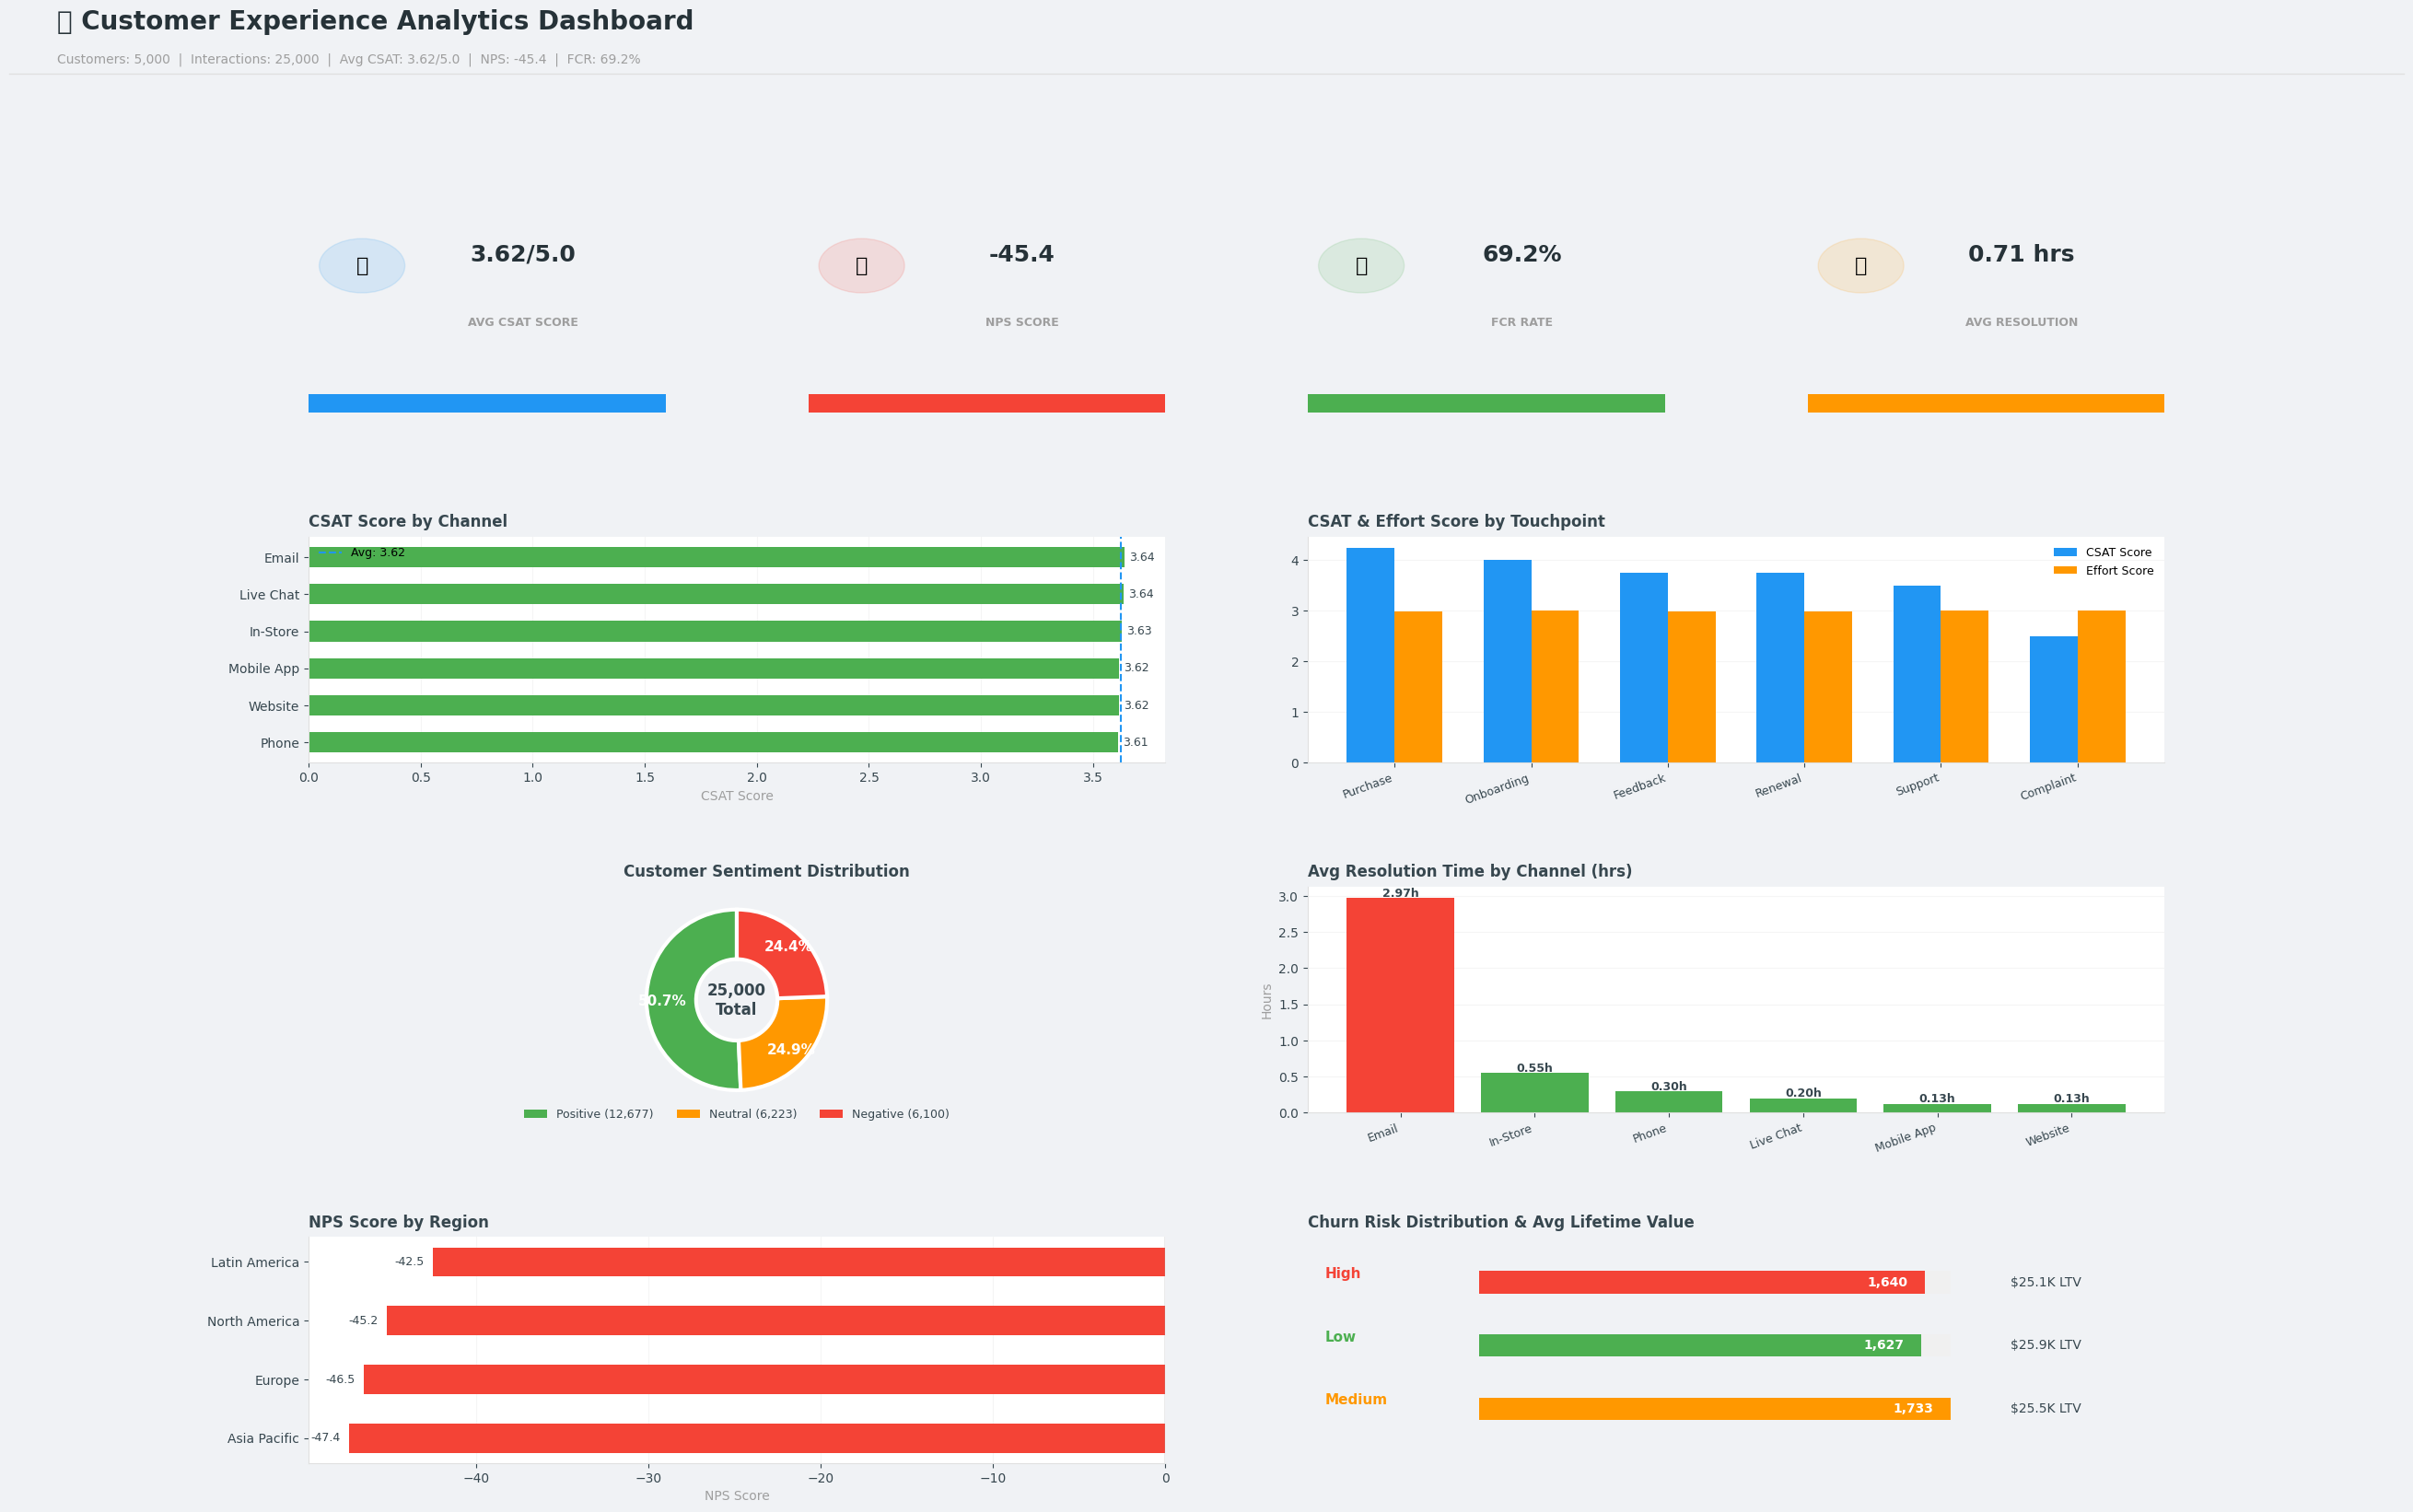

Customer Experience Dashboard created!


In [4]:
# Customer Experience Analytics Dashboard
plt.rcParams.update({
    'font.size': 11, 'axes.titlesize': 13,
    'axes.labelsize': 11, 'xtick.labelsize': 10,
    'ytick.labelsize': 10
})

plt.style.use('default')
fig = plt.figure(figsize=(26, 18))
fig.patch.set_facecolor('#f0f2f5')
gs = gridspec.GridSpec(4, 4, figure=fig, hspace=0.55, wspace=0.40)

BLUE = '#2196F3'
GREEN = '#4CAF50'
RED = '#f44336'
ORANGE = '#FF9800'
PURPLE = '#9b59b6'
TEAL = '#009688'
CARD = '#ffffff'
BORDER = '#e0e0e0'
TEXT = '#37474f'
GRAY = '#9e9e9e'
DARK = '#263238'

def card(ax):
    ax.set_facecolor(CARD)
    for spine in ax.spines.values():
        spine.set_color(BORDER)
        spine.set_linewidth(0.8)

# ── HEADER ─────────────────────────────────────────
fig.text(0.02, 0.975, '⭐ Customer Experience Analytics Dashboard',
         ha='left', fontsize=20, fontweight='bold', color=DARK)
fig.text(0.02, 0.955,
         f'Customers: {len(customers_df):,}  |  Interactions: {len(cx_df):,}  |  Avg CSAT: {cx_df["csat_score"].mean():.2f}/5.0  |  NPS: {nps:.1f}  |  FCR: {cx_df["first_contact_resolution"].mean()*100:.1f}%',
         ha='left', fontsize=10, color=GRAY)
fig.add_artist(plt.Line2D([0.0, 1.0], [0.948, 0.948],
               color=BORDER, linewidth=1.0, transform=fig.transFigure))

# ── KPI CARDS ──────────────────────────────────────
kpis = [
    ('AVG CSAT SCORE', f'{cx_df["csat_score"].mean():.2f}/5.0', BLUE, '⭐'),
    ('NPS SCORE', f'{nps:.1f}', RED if nps < 0 else GREEN, '📊'),
    ('FCR RATE', f'{cx_df["first_contact_resolution"].mean()*100:.1f}%', GREEN, '✅'),
    ('AVG RESOLUTION', f'{cx_df["resolution_time_hrs"].mean():.2f} hrs', ORANGE, '⏱'),
]

for idx, (label, value, color, icon) in enumerate(kpis):
    ax_kpi = fig.add_subplot(gs[0, idx])
    card(ax_kpi)
    ax_kpi.axis('off')
    circle = plt.Circle((0.15, 0.65), 0.12, color=color+'22',
                        transform=ax_kpi.transAxes)
    ax_kpi.add_patch(circle)
    ax_kpi.text(0.15, 0.65, icon, ha='center', va='center',
                transform=ax_kpi.transAxes, fontsize=16)
    ax_kpi.text(0.60, 0.70, value, ha='center', va='center',
                transform=ax_kpi.transAxes, fontsize=18,
                fontweight='bold', color=DARK)
    ax_kpi.text(0.60, 0.40, label, ha='center', va='center',
                transform=ax_kpi.transAxes, fontsize=9,
                color=GRAY, fontweight='bold')
    ax_kpi.add_patch(mpatches.FancyBboxPatch((0.0, 0.0), 1.0, 0.08,
                      boxstyle="square,pad=0", facecolor=color,
                      edgecolor='none', transform=ax_kpi.transAxes))

# ── CHART 1: CSAT by Channel ────────────────────────
ax1 = fig.add_subplot(gs[1, 0:2])
card(ax1)
ax1.set_title('CSAT Score by Channel', color=TEXT,
              fontweight='bold', loc='left', pad=8)
channel_csat = cx_df.groupby('channel')['csat_score'].mean().sort_values()
channel_colors = [GREEN if v >= 3.5 else ORANGE if v >= 3.0 else RED
                  for v in channel_csat.values]
bars1 = ax1.barh(channel_csat.index, channel_csat.values,
                 color=channel_colors, edgecolor='none', height=0.55)
ax1.axvline(cx_df['csat_score'].mean(), color=BLUE, linestyle='--',
            linewidth=1.5, label=f'Avg: {cx_df["csat_score"].mean():.2f}')
ax1.tick_params(colors=TEXT, labelsize=10)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(axis='x', color='#f5f5f5', linewidth=0.8)
ax1.set_axisbelow(True)
ax1.set_xlabel('CSAT Score', color=GRAY)
ax1.legend(fontsize=9, frameon=False)
for bar, val in zip(bars1, channel_csat.values):
    ax1.text(val + 0.02, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}', va='center', fontsize=9, color=TEXT)

# ── CHART 2: Touchpoint Analysis ───────────────────
ax2 = fig.add_subplot(gs[1, 2:4])
card(ax2)
ax2.set_title('CSAT & Effort Score by Touchpoint', color=TEXT,
              fontweight='bold', loc='left', pad=8)
tp_stats = cx_df.groupby('touchpoint').agg(
    csat=('csat_score', 'mean'),
    effort=('effort_score', 'mean')
).reset_index().sort_values('csat', ascending=False)
x = np.arange(len(tp_stats))
width = 0.35
bars2a = ax2.bar(x - width/2, tp_stats['csat'], width,
                 color=BLUE, edgecolor='none', label='CSAT Score')
bars2b = ax2.bar(x + width/2, tp_stats['effort'], width,
                 color=ORANGE, edgecolor='none', label='Effort Score')
ax2.set_xticks(x)
ax2.set_xticklabels(tp_stats['touchpoint'], rotation=20,
                    ha='right', color=TEXT, fontsize=9)
ax2.tick_params(colors=TEXT)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(axis='y', color='#f5f5f5', linewidth=0.8)
ax2.set_axisbelow(True)
ax2.legend(fontsize=9, frameon=False)

# ── CHART 3: Sentiment Distribution Donut ──────────
ax3 = fig.add_subplot(gs[2, 0:2])
card(ax3)
ax3.set_title('Customer Sentiment Distribution', color=TEXT,
              fontweight='bold', loc='left', pad=8)
sentiment_counts = cx_df['sentiment'].value_counts()
sentiment_colors = {'Positive': GREEN, 'Neutral': ORANGE, 'Negative': RED}
colors_pie = [sentiment_colors[s] for s in sentiment_counts.index]
wedges, texts, autotexts = ax3.pie(
    sentiment_counts.values,
    colors=colors_pie,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.82,
    wedgeprops={'edgecolor': 'white', 'linewidth': 3, 'width': 0.55}
)
for text in texts:
    text.set_visible(False)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')
ax3.text(0, 0, f'{len(cx_df):,}\nTotal', ha='center', va='center',
         fontsize=12, fontweight='bold', color=TEXT)
legend_elements = [mpatches.Patch(facecolor=colors_pie[i],
                   label=f'{sentiment_counts.index[i]} ({sentiment_counts.values[i]:,})')
                   for i in range(len(sentiment_counts))]
ax3.legend(handles=legend_elements, loc='lower center', ncol=3,
           fontsize=9, frameon=False, labelcolor=TEXT,
           bbox_to_anchor=(0.5, -0.08))

# ── CHART 4: Resolution Time by Channel ────────────
ax4 = fig.add_subplot(gs[2, 2:4])
card(ax4)
ax4.set_title('Avg Resolution Time by Channel (hrs)', color=TEXT,
              fontweight='bold', loc='left', pad=8)
res_time = cx_df.groupby('channel')['resolution_time_hrs'].mean().sort_values(ascending=False)
colors4 = [RED if v > 2 else ORANGE if v > 1 else GREEN for v in res_time.values]
bars4 = ax4.bar(range(len(res_time)), res_time.values,
                color=colors4, edgecolor='none')
ax4.set_xticks(range(len(res_time)))
ax4.set_xticklabels(res_time.index, rotation=20,
                    ha='right', color=TEXT, fontsize=9)
ax4.tick_params(colors=TEXT)
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)
ax4.grid(axis='y', color='#f5f5f5', linewidth=0.8)
ax4.set_axisbelow(True)
ax4.set_ylabel('Hours', color=GRAY)
for bar, val in zip(bars4, res_time.values):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.2f}h', ha='center', fontsize=9, color=TEXT,
             fontweight='bold')

# ── CHART 5: NPS by Region ─────────────────────────
ax5 = fig.add_subplot(gs[3, 0:2])
card(ax5)
ax5.set_title('NPS Score by Region', color=TEXT,
              fontweight='bold', loc='left', pad=8)
def calc_nps(scores):
    p = (scores >= 9).sum()
    d = (scores <= 6).sum()
    return ((p - d) / len(scores)) * 100

region_nps = customers_df.groupby('region')['nps_score'].apply(calc_nps).sort_values()
colors5 = [GREEN if v >= 0 else RED for v in region_nps.values]
bars5 = ax5.barh(region_nps.index, region_nps.values,
                 color=colors5, edgecolor='none', height=0.5)
ax5.axvline(0, color=GRAY, linewidth=1.0)
ax5.tick_params(colors=TEXT, labelsize=10)
ax5.spines['top'].set_visible(False)
ax5.spines['right'].set_visible(False)
ax5.grid(axis='x', color='#f5f5f5', linewidth=0.8)
ax5.set_axisbelow(True)
ax5.set_xlabel('NPS Score', color=GRAY)
for bar, val in zip(bars5, region_nps.values):
    x_pos = val + 0.5 if val >= 0 else val - 0.5
    ax5.text(x_pos, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}', va='center', fontsize=9,
             color=TEXT, ha='left' if val >= 0 else 'right')

# ── CHART 6: Churn Risk & LTV ──────────────────────
ax6 = fig.add_subplot(gs[3, 2:4])
card(ax6)
ax6.set_title('Churn Risk Distribution & Avg Lifetime Value', color=TEXT,
              fontweight='bold', loc='left', pad=8)
ax6.axis('off')

churn_stats = customers_df.groupby('churn_risk').agg(
    count=('customer_id', 'count'),
    avg_ltv=('lifetime_value', 'mean')
).reset_index()

churn_colors = {'Low': GREEN, 'Medium': ORANGE, 'High': RED}
for idx, row in churn_stats.iterrows():
    y = 0.82 - idx * 0.28
    color = churn_colors[row['churn_risk']]
    ax6.text(0.02, y, row['churn_risk'], transform=ax6.transAxes,
             fontsize=11, color=color, fontweight='bold')
    fill_w = 0.55 * row['count'] / churn_stats['count'].max()
    ax6.add_patch(mpatches.FancyBboxPatch((0.20, y-0.07), 0.55, 0.10,
                   boxstyle="square,pad=0", facecolor='#f0f0f0',
                   edgecolor='none', transform=ax6.transAxes))
    ax6.add_patch(mpatches.FancyBboxPatch((0.20, y-0.07), fill_w, 0.10,
                   boxstyle="square,pad=0", facecolor=color,
                   edgecolor='none', transform=ax6.transAxes))
    ax6.text(0.20 + fill_w - 0.02, y - 0.02, f'{row["count"]:,}',
             transform=ax6.transAxes, fontsize=10,
             color='white', fontweight='bold', ha='right', va='center')
    ax6.text(0.82, y - 0.02, f'${row["avg_ltv"]/1e3:.1f}K LTV',
             transform=ax6.transAxes, fontsize=10, color=TEXT, va='center')

plt.savefig('customer_experience_dashboard.png', dpi=150,
            bbox_inches='tight', facecolor='#f0f2f5')
plt.show()
print("Customer Experience Dashboard created!")

In [6]:
from google.colab import files

# Save dataset
cx_df.to_csv('customer_experience_data.csv', index=False)
customers_df.to_csv('customers_data.csv', index=False)

# Save README
results = """
# Customer Experience Analytics Dashboard

## Overview
- **Total Customers:** {:,}
- **Total Interactions:** {:,}
- **Avg CSAT Score:** {:.2f}/5.0
- **NPS Score:** {:.1f}
- **FCR Rate:** {:.1f}%
- **Avg Resolution Time:** {:.2f} hrs
- **Avg Effort Score:** {:.2f}/5.0

## Dashboard Sections
1. KPI Cards — CSAT, NPS, FCR Rate, Resolution Time
2. CSAT Score by Channel
3. CSAT & Effort Score by Touchpoint
4. Customer Sentiment Distribution
5. Avg Resolution Time by Channel
6. NPS Score by Region
7. Churn Risk Distribution & Avg Lifetime Value

## Technologies
- Python, Pandas, NumPy
- Matplotlib, Seaborn
- Google Colab (T4 GPU)
""".format(
    len(customers_df),
    len(cx_df),
    cx_df['csat_score'].mean(),
    nps,
    cx_df['first_contact_resolution'].mean()*100,
    cx_df['resolution_time_hrs'].mean(),
    cx_df['effort_score'].mean()
)

with open('README_results.md', 'w') as f:
    f.write(results)

print("Downloading files...")
files.download('customer_experience_dashboard.png')
files.download('customer_experience_data.csv')
files.download('customers_data.csv')
files.download('README_results.md')
print("All files downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All files downloaded!
